## LANGCHAIN INTRO

In [1]:
#load the API

import os 
from dotenv import find_dotenv, load_dotenv

load_dotenv(find_dotenv(usecwd=True), override=True)
os.environ["OPENAI_API_KEY"] = os.getenv("OPENAI_API_KEY")
os.environ["GROQ_API_KEY"] = os.getenv("GROQ_API_KEY")
print("API Key Loaded:", os.getenv("GROQ_API_KEY")[:10] if os.getenv("GROQ_API_KEY") else "FAILED TO LOAD")



API Key Loaded: gsk_8yEZ0T


In [3]:
#Test the API KEY
from langchain_groq import ChatGroq
from langchain_openai import ChatOpenAI #alternative 

llm = ChatGroq(model ="qwen/qwen3.6-27b" )
print(llm.invoke("hello, tell me about yourself in few words").content)


<think>
Here's a thinking process:

1.  **Analyze User Input:**
   - **Greeting:** "hello"
   - **Request:** "tell me about yourself in few words"
   - **Key Constraint:** "in few words" (concise, brief)

2.  **Identify Core Requirements:**
   - Acknowledge greeting
   - Provide a brief self-description
   - Keep it short and to the point
   - Maintain helpful, friendly tone

3.  **Determine Key Information to Include:**
   - I'm an AI assistant
   - I help with questions, tasks, learning, and problem-solving
   - I'm designed to be helpful, accurate, and conversational
   - Keep it to 1-2 sentences max

4.  **Draft (Mental):**
   Hello! I'm a helpful AI assistant designed to answer questions, solve problems, and chat with you. I'm here to make your day easier and more productive.

5.  **Refine (Check against constraints):**
   - Greeting acknowledged? Yes
   - About myself? Yes
   - Few words? ~20 words, concise
   - Tone appropriate? Yes, friendly and professional

   Could be even 

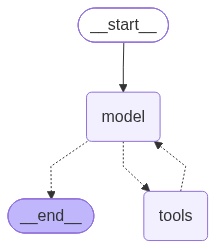

In [4]:
#Create a Basic Agent
from langchain.agents import create_agent

def get_weather(city:str) -> str:
    """ Get the weather for a city"""
    return f"the weather in {city} is sunny" #printing a default 

agent = create_agent(
        model = llm,
        tools = [get_weather],
        system_prompt=" you are a helpful Ai assistance"

)

agent

In [14]:

response = agent.invoke(
    {"messages": [("user", "what is the weather today in Tokyo")]})

print(response)

{'messages': [HumanMessage(content='what is the weather today in Tokyo', additional_kwargs={}, response_metadata={}, id='c5a99743-7133-4908-9ad1-66b013d98ade'), AIMessage(content='', additional_kwargs={'tool_calls': [{'id': 'j466n9byv', 'function': {'arguments': '{"city":"Tokyo"}', 'name': 'get_weather'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 15, 'prompt_tokens': 225, 'total_tokens': 240, 'completion_time': 0.048116247, 'completion_tokens_details': None, 'prompt_time': 0.022421715, 'prompt_tokens_details': None, 'queue_time': 0.051145835, 'total_time': 0.070537962}, 'model_name': 'llama-3.3-70b-versatile', 'system_fingerprint': 'fp_dae98b5ecb', 'service_tier': 'on_demand', 'finish_reason': 'tool_calls', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019ffa09-7fb1-70a1-90e5-a2fb87d42958-0', tool_calls=[{'name': 'get_weather', 'args': {'city': 'Tokyo'}, 'id': 'j466n9byv', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'inp

In [19]:
#STREAMING 
for chunk in llm.stream("Why do parrot talk?"):
    print(chunk.text, end = "|", flush = True) #flush: Text streams smoothly in real-time.

|Par|rots| are| known| for| their| remarkable| ability| to| mimic| human| speech| and| other| sounds| they| hear| in| their| environment|.| While| we| can|'t| directly| ask| a| par|rot| why| it| talks|,| scientists| have| made| several| observations| and| theories| about| their| vocal| behavior|.| Here| are| some| reasons| why| par|rots| might| "|talk|":

|1|.| **|Communication| and| social| bonding|**:| In| the| wild|,| par|rots| use| vocal|izations| to| communicate| with| each| other|,| conveying| information| about| food|,| predators|,| and| potential| mates|.| They| may| also| use| vocal|izations| to| strengthen| social| bonds| within| their| flock|.| When| kept| as| pets|,| par|rots| may| extend| this| behavior| to| their| human| caregivers|,| using| vocal|izations| to| initiate| interaction|,| seek| attention|,| or| express| affection|.
|2|.| **|M|im|ic|ry| and| learning|**:| Par|rots| are| renowned| for| their| ability| to| mimic| sounds|,| including| human| speech|.| They| have

In [23]:
#BATCH Processing : take all teh individual request and works in parallely and get the result

response = llm.batch( 
    ["why do parrots talk?",
    "How do airplanes fly",
    "How long parrots can fly "
    ], config = {"max_concurrency": 5}
)

for responses in response:
    print(responses.content)

Parrots are known for their impressive ability to mimic human speech and other sounds, but why do they do it? There are several theories:

1. **Communication and Social Bonding**: In the wild, parrots use vocalizations to communicate with each other, establish social bonds, and warn other parrots of potential threats. By mimicking human speech, parrots may be attempting to communicate with their human caregivers and form a social bond.
2. **Learning and Imitation**: Parrots are highly intelligent birds, and they have a strong instinct to learn and imitate sounds they hear. They may learn to mimic human speech as a way to entertain themselves, get attention, or simply because it's a fun activity.
3. **Attention and Reward**: Parrots are highly social animals and thrive on attention. When they mimic human speech, they may receive attention, praise, or rewards from their owners, which can reinforce the behavior.
4. **Contextual Learning**: Parrots may learn to associate certain words or p